# Construção das tabelas analíticas — Camada Gold

Este notebook utiliza as tabelas da camada Silver para analisar o desempenho das vendas e sua relação com a experiência do cliente.

## Perguntas da análise

1. Como evoluíram os pedidos e o valor dos itens vendidos por mês?
2. Quais categorias apresentaram maior valor de itens vendidos?
3. Como as notas das avaliações se relacionam com os atrasos nas entregas?

## Critérios dos indicadores

- As análises consideram pedidos com status `delivered`.
- O valor dos itens vendidos corresponde à soma de `price`, sem frete. Esse indicador não representa receita líquida ou lucro da Olist.
- A evolução mensal utiliza o mês da compra.
- Produtos sem categoria são agrupados como “Não informada”.
- Os nomes originais das categorias são preservados nas tabelas. Nos gráficos, alguns rótulos são ajustados para facilitar a leitura.
- A análise de atrasos exige datas de compra, envio, entrega e previsão preenchidas, com envio igual ou posterior à compra, entrega igual ou posterior ao envio e previsão igual ou posterior à compra.
- Uma entrega é considerada atrasada quando ocorre em um dia posterior à data prevista.
- São consideradas válidas as notas entre 1 e 5. Quando existem várias avaliações para um pedido, utiliza-se sua média, garantindo o mesmo peso para cada pedido.
- Pedidos sem avaliação válida permanecem na contagem de entregas, mas não participam da média das notas.
- A comparação entre atraso e avaliação é descritiva e não demonstra causalidade.

## Organização das análises

Na evolução mensal, os itens são agregados por pedido antes da associação aos pedidos entregues. Na análise por categoria, a agregação ocorre por categoria dos produtos. Um pedido pode conter itens de diferentes categorias, portanto suas contagens não devem ser somadas para obter o total geral de pedidos.

Na análise de pontualidade, as avaliações são agregadas por pedido antes da associação às entregas, evitando que pedidos com várias avaliações tenham maior peso.

Os resultados são salvos em três tabelas Delta no esquema `olist_mvp.gold`: `vendas_mensais`, `vendas_por_categoria` e `avaliacoes_por_atraso`. Cada análise apresenta seus resultados, visualizações e interpretação, seguida de uma conclusão com limitações e próximos passos.

In [0]:
from pyspark.sql import functions as F

spark.sql("CREATE SCHEMA IF NOT EXISTS olist_mvp.gold")

pedidos_entregues = (
    spark.table("olist_mvp.silver.orders")
    .filter(F.col("order_status") == "delivered")
)

# A agregação mantém uma linha por pedido antes da associação.
itens_por_pedido = (
    spark.table("olist_mvp.silver.order_items")
    .groupBy("order_id")
    .agg(
        F.sum("price").alias("valor_itens"),
        F.count("*").alias("quantidade_itens")
    )
)

base_vendas = pedidos_entregues.join(
    itens_por_pedido,
    on="order_id",
    how="left"
)

vendas_mensais = (
    base_vendas
    .filter(F.col("order_purchase_timestamp").isNotNull())
    .withColumn(
        "mes_compra",
        F.trunc(F.to_date("order_purchase_timestamp"), "month")
    )
    .groupBy("mes_compra")
    .agg(
        F.count("*").alias("quantidade_pedidos"),
        F.count("valor_itens").alias("pedidos_com_itens"),
        F.sum("quantidade_itens").alias("quantidade_itens"),
        F.sum("valor_itens").alias("valor_total_itens"),
        F.round(F.avg("valor_itens"), 2).alias(
            "valor_medio_itens_por_pedido"
        )
    )
)

(
    vendas_mensais.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("olist_mvp.gold.vendas_mensais")
)

display(vendas_mensais.orderBy("mes_compra"))

mes_compra,quantidade_pedidos,pedidos_com_itens,quantidade_itens,valor_total_itens,valor_medio_itens_por_pedido
2016-09-01,1,1,3,134.97,134.97
2016-10-01,265,265,313,40325.11,152.17
2016-12-01,1,1,1,10.90,10.90
2017-01-01,750,750,913,111798.36,149.06
2017-02-01,1653,1653,1858,234223.40,141.70
2017-03-01,2546,2546,2897,359198.85,141.08
2017-04-01,2303,2303,2569,340669.68,147.92
2017-05-01,3546,3546,4004,489338.25,138.00
2017-06-01,3135,3135,3489,421923.37,134.58
2017-07-01,3872,3872,4416,481604.52,124.38


### Evolução mensal das vendas

A tabela reúne os pedidos entregues por mês da compra. O valor das vendas corresponde à soma dos preços dos itens, sem incluir frete, e não representa a receita líquida da Olist.

A comparação entre quantidade de pedidos e pedidos com itens permite verificar a cobertura da associação entre as tabelas. O valor médio dos itens por pedido complementa o volume de vendas, permitindo distinguir crescimento na quantidade de pedidos de mudanças no valor das compras.

Os gráficos a seguir apresentam a evolução desses indicadores no período disponível. Meses com poucos registros e os limites temporais da base exigem cautela: variações observadas não demonstram, por si só, mudanças na demanda.

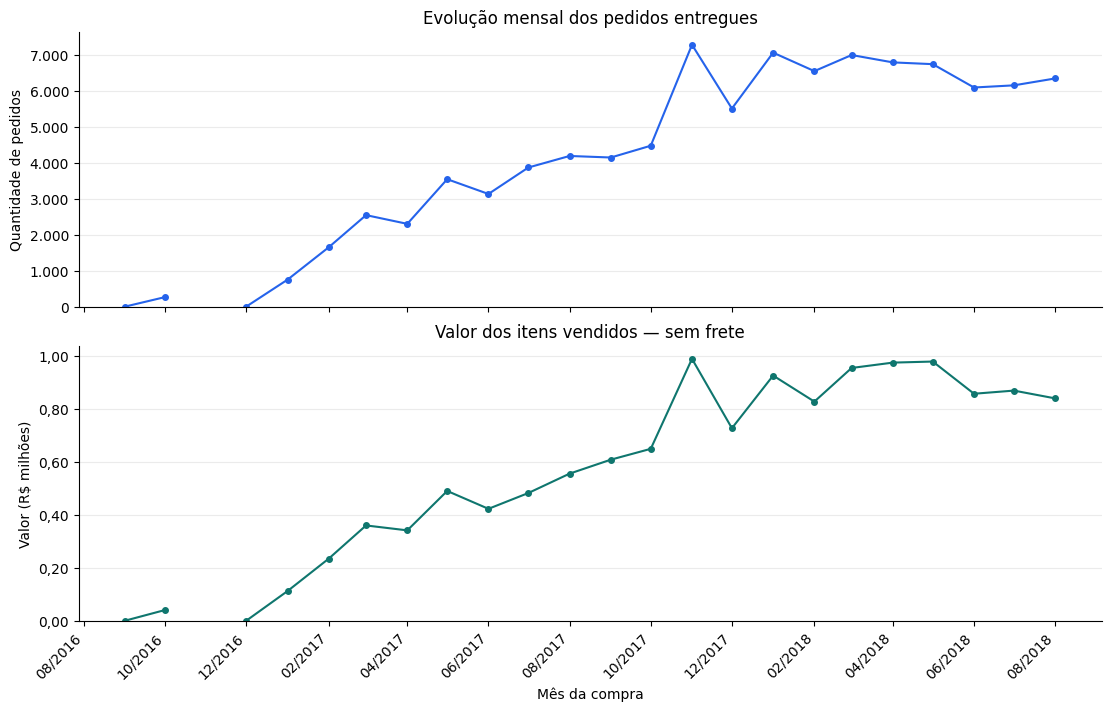

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

dados_mensais = (
    spark.table("olist_mvp.gold.vendas_mensais")
    .orderBy("mes_compra")
    .toPandas()
)

dados_mensais["mes_compra"] = pd.to_datetime(
    dados_mensais["mes_compra"]
)

dados_mensais["valor_total_itens"] = (
    dados_mensais["valor_total_itens"].astype(float)
)

# Meses sem registros permanecem como lacunas no gráfico.
dados_mensais = (
    dados_mensais
    .set_index("mes_compra")
    .asfreq("MS")
)

figura, eixos = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True,
    constrained_layout=True
)

eixos[0].plot(
    dados_mensais.index,
    dados_mensais["quantidade_pedidos"],
    color="#2563EB", marker="o", markersize=4
)
eixos[0].set_title("Evolução mensal dos pedidos entregues")
eixos[0].set_ylabel("Quantidade de pedidos")
eixos[0].yaxis.set_major_formatter(
    FuncFormatter(lambda valor, posicao: f"{valor:,.0f}".replace(",", "."))
)

eixos[1].plot(
    dados_mensais.index,
    dados_mensais["valor_total_itens"] / 1_000_000,
    color="#0F766E", marker="o", markersize=4
)
eixos[1].set_title("Valor dos itens vendidos — sem frete")
eixos[1].set_ylabel("Valor (R$ milhões)")
eixos[1].set_xlabel("Mês da compra")
eixos[1].yaxis.set_major_formatter(
    FuncFormatter(lambda valor, posicao: f"{valor:.2f}".replace(".", ","))
)

eixos[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
eixos[1].xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))

for eixo in eixos:
    eixo.set_ylim(bottom=0)
    eixo.grid(axis="y", alpha=0.25)
    eixo.spines["top"].set_visible(False)
    eixo.spines["right"].set_visible(False)

plt.setp(eixos[1].get_xticklabels(), rotation=45, ha="right")
plt.show()

### Interpretação da evolução mensal

Ao longo de 2017, observa-se crescimento na quantidade de pedidos entregues e no valor dos itens vendidos. Novembro apresenta o maior volume mensal do período, com 7.289 pedidos e aproximadamente R$ 1 milhão em itens, seguido de queda em dezembro.

Em 2018, os pedidos permanecem em um patamar superior ao observado no início de 2017, mas sem crescimento contínuo. O valor mensal dos itens acompanha parte dessas oscilações, embora os dois indicadores não variem na mesma proporção, pois o valor médio por pedido também muda.

O pico de novembro sugere investigar possíveis efeitos de campanhas comerciais e sazonalidade. Entretanto, esta análise não permite atribuí-lo a uma campanha específica nem estabelecer um padrão sazonal recorrente.

Os poucos registros de 2016 e a cobertura limitada a parte de 2018 dificultam comparações entre totais anuais. Além disso, os resultados representam apenas os pedidos com status de entregue presentes na base.

Após observar a evolução temporal, a próxima análise identifica quais categorias concentram o maior valor de itens vendidos.

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

pedidos_entregues = (
    spark.table("olist_mvp.silver.orders")
    .filter(F.col("order_status") == "delivered")
    .select("order_id")
)

itens = spark.table("olist_mvp.silver.order_items")

produtos = (
    spark.table("olist_mvp.silver.products")
    .select("product_id", "product_category_name")
)

vendas_por_categoria = (
    itens
    .join(pedidos_entregues, on="order_id", how="inner")
    .join(produtos, on="product_id", how="left")
    .withColumn(
        "categoria",
        F.coalesce(
            F.col("product_category_name"),
            F.lit("Não informada")
        )
    )
    .groupBy("categoria")
    .agg(
        F.countDistinct("order_id").alias("quantidade_pedidos"),
        F.count("*").alias("quantidade_itens"),
        F.sum("price").alias("valor_total_itens")
    )
)

# O denominador inclui todas as categorias, inclusive “Não informada”.
janela_total = Window.partitionBy()

vendas_por_categoria = (
    vendas_por_categoria
    .withColumn(
        "_total_geral",
        F.sum("valor_total_itens").over(janela_total)
    )
    .withColumn(
        "participacao_percentual",
        F.when(
            F.col("_total_geral") > 0,
            F.round(
                100 * F.col("valor_total_itens") / F.col("_total_geral"),
                2
            )
        )
    )
    .drop("_total_geral")
)

(
    vendas_por_categoria.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("olist_mvp.gold.vendas_por_categoria")
)

display(
    vendas_por_categoria.orderBy(
        F.desc("valor_total_itens"),
        "categoria"
    )
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1163: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


categoria,quantidade_pedidos,quantidade_itens,valor_total_itens,participacao_percentual
beleza_saude,8647,9465,1233131.72,9.33
relogios_presentes,5495,5859,1166176.98,8.82
cama_mesa_banho,9272,10953,1023434.76,7.74
esporte_lazer,7530,8431,954852.55,7.22
informatica_acessorios,6530,7644,888724.61,6.72
moveis_decoracao,6307,8160,711927.69,5.38
utilidades_domesticas,5743,6795,615628.69,4.66
cool_stuff,3559,3718,610204.10,4.62
automotivo,3810,4140,578966.65,4.38
brinquedos,3804,4030,471286.48,3.56


### Vendas por categoria

A tabela apresenta a quantidade de pedidos, a quantidade de itens,
o valor dos itens vendidos e a participação percentual de cada
categoria no valor total dos itens vendidos em pedidos entregues.

O valor considera apenas o preço dos itens, sem frete. O cálculo
das participações inclui todas as categorias, inclusive os produtos
classificados como “Não informada”.

Um pedido pode conter produtos de diferentes categorias. Por isso,
as contagens de pedidos por categoria não devem ser somadas para
obter o total geral de pedidos.

O gráfico a seguir apresenta as dez categorias com maior valor
de itens vendidos.

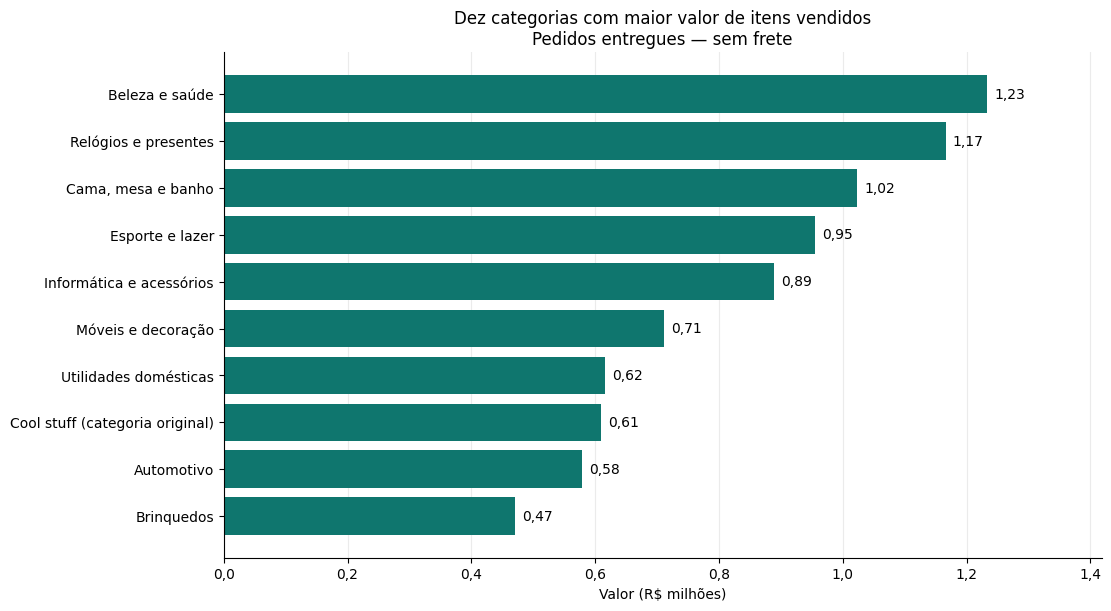

In [0]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pyspark.sql import functions as F

dados_categorias = (
    spark.table("olist_mvp.gold.vendas_por_categoria")
    .orderBy(F.desc("valor_total_itens"), "categoria")
    .limit(10)
    .toPandas()
)

# Os rótulos de apresentação não alteram os nomes salvos na tabela.
nomes_exibicao = {
    "beleza_saude": "Beleza e saúde",
    "relogios_presentes": "Relógios e presentes",
    "cama_mesa_banho": "Cama, mesa e banho",
    "esporte_lazer": "Esporte e lazer",
    "informatica_acessorios": "Informática e acessórios",
    "moveis_decoracao": "Móveis e decoração",
    "utilidades_domesticas": "Utilidades domésticas",
    "cool_stuff": "Cool stuff (categoria original)",
    "automotivo": "Automotivo",
    "brinquedos": "Brinquedos"
}

rotulos = dados_categorias["categoria"].map(
    lambda nome: nomes_exibicao.get(nome, nome.replace("_", " "))
)

valores = dados_categorias["valor_total_itens"].astype(float) / 1_000_000

figura, eixo = plt.subplots(
    figsize=(11, 6), constrained_layout=True
)

barras = eixo.barh(rotulos, valores, color="#0F766E")
eixo.invert_yaxis()

eixo.bar_label(
    barras,
    labels=[f"{valor:.2f}".replace(".", ",") for valor in valores],
    padding=5
)

eixo.set_title(
    "Dez categorias com maior valor de itens vendidos\n"
    "Pedidos entregues — sem frete"
)
eixo.set_xlabel("Valor (R$ milhões)")
eixo.set_xlim(0, valores.max() * 1.15)
eixo.xaxis.set_major_formatter(
    FuncFormatter(lambda valor, posicao: f"{valor:.1f}".replace(".", ","))
)

eixo.set_axisbelow(True)
eixo.grid(axis="x", alpha=0.25)
eixo.spines["top"].set_visible(False)
eixo.spines["right"].set_visible(False)

plt.show()

### Interpretação das principais categorias

O valor total dos itens vendidos em pedidos entregues foi de
R$ 13.221.498,11, sem frete. Beleza e saúde representa 9,33%
desse total, seguida por Relógios e presentes (8,82%) e
Cama, mesa e banho (7,74%).

As três categorias líderes somam 25,89% do valor vendido.
As dez categorias apresentadas no gráfico concentram 62,43%,
indicando sua relevância para acompanhar o desempenho comercial.
Os percentuais conjuntos foram calculados a partir dos valores
monetários, antes do arredondamento das participações individuais.

O denominador inclui todas as categorias, inclusive o grupo
“Não informada”, responsável por 1,29% do valor total.
Assim, as participações não se restringem às categorias
exibidas no gráfico.

Essa concentração pode orientar prioridades de acompanhamento
comercial e operacional, mas não demonstra maior lucratividade,
pois não foram considerados custos, comissões ou margens.

Além do desempenho comercial, é necessário examinar a experiência
do cliente. A próxima análise compara as notas dos pedidos
entregues no prazo com as dos pedidos atrasados.

In [0]:
from pyspark.sql import functions as F

pedidos_entregues = (
    spark.table("olist_mvp.silver.orders")
    .filter(F.col("order_status") == "delivered")
)

# Cada pedido recebe uma nota média, mesmo quando possui várias avaliações.
avaliacoes_por_pedido = (
    spark.table("olist_mvp.silver.reviews")
    .filter(F.col("review_score").between(1, 5))
    .groupBy("order_id")
    .agg(F.avg("review_score").alias("nota_media_pedido"))
)

datas_consistentes = (
    F.col("order_purchase_timestamp").isNotNull()
    & F.col("order_delivered_carrier_date").isNotNull()
    & F.col("order_delivered_customer_date").isNotNull()
    & F.col("order_estimated_delivery_date").isNotNull()
    & (
        F.col("order_delivered_carrier_date")
        >= F.col("order_purchase_timestamp")
    )
    & (
        F.col("order_delivered_customer_date")
        >= F.col("order_delivered_carrier_date")
    )
    & (
        F.col("order_estimated_delivery_date")
        >= F.col("order_purchase_timestamp")
    )
)

base_entregas = (
    pedidos_entregues
    .filter(datas_consistentes)
    .withColumn(
        "dias_apos_prazo",
        F.datediff(
            F.to_date("order_delivered_customer_date"),
            F.to_date("order_estimated_delivery_date")
        )
    )
    .withColumn(
        "situacao_entrega",
        F.when(
            F.col("dias_apos_prazo") > 0, "Com atraso"
        ).otherwise("No prazo")
    )
    .join(avaliacoes_por_pedido, on="order_id", how="left")
)

avaliacoes_por_atraso = (
    base_entregas
    .groupBy("situacao_entrega")
    .agg(
        F.count("*").alias("quantidade_pedidos"),
        F.count("nota_media_pedido").alias("pedidos_com_avaliacao"),
        F.round(F.avg("nota_media_pedido"), 2).alias("nota_media"),
        F.round(
            F.avg(
                F.when(
                    F.col("dias_apos_prazo") > 0,
                    F.col("dias_apos_prazo")
                )
            ),
            2
        ).alias("media_dias_atraso")
    )
)

(
    avaliacoes_por_atraso.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("olist_mvp.gold.avaliacoes_por_atraso")
)

display(avaliacoes_por_atraso.orderBy("situacao_entrega"))

total_entregues = pedidos_entregues.count()
total_analisados = base_entregas.count()

print(f"Pedidos entregues: {total_entregues}")
print(f"Pedidos incluídos na análise: {total_analisados}")
print(
    "Pedidos excluídos por datas ausentes ou inconsistentes: "
    f"{total_entregues - total_analisados}"
)

situacao_entrega,quantidade_pedidos,pedidos_com_avaliacao,nota_media,media_dias_atraso
Com atraso,6531,6378,2.27,10.62
No prazo,89750,89258,4.29,null


Pedidos entregues: 96478
Pedidos incluídos na análise: 96281
Pedidos excluídos por datas ausentes ou inconsistentes: 197


### Pontualidade das entregas e avaliações

A análise inclui 96.281 pedidos entregues com as datas necessárias preenchidas e cronologicamente consistentes. Desse total, 6.531 apresentaram atraso, aproximadamente 6,78%, e 89.750 foram entregues no prazo.

Foram encontradas avaliações válidas para 95.636 pedidos. Quando um pedido possui mais de uma avaliação, utiliza-se sua nota média, garantindo o mesmo peso para cada pedido na comparação.

Os pedidos atrasados apresentam nota média de 2,27, enquanto os entregues no prazo alcançam 4,29. Entre os pedidos atrasados, o atraso médio é de 10,62 dias. Para o grupo entregue no prazo, esse indicador não se aplica.

Pedidos sem avaliação permanecem na contagem de entregas, mas não participam do cálculo das notas médias. O gráfico a seguir apresenta a diferença entre os grupos.

Dos 96.478 pedidos entregues, 197 foram excluídos desta análise por datas ausentes ou inconsistentes, aproximadamente 0,20% do total. Esses registros permanecem na camada Silver. A comparação de pontualidade abrange os 96.281 pedidos restantes.

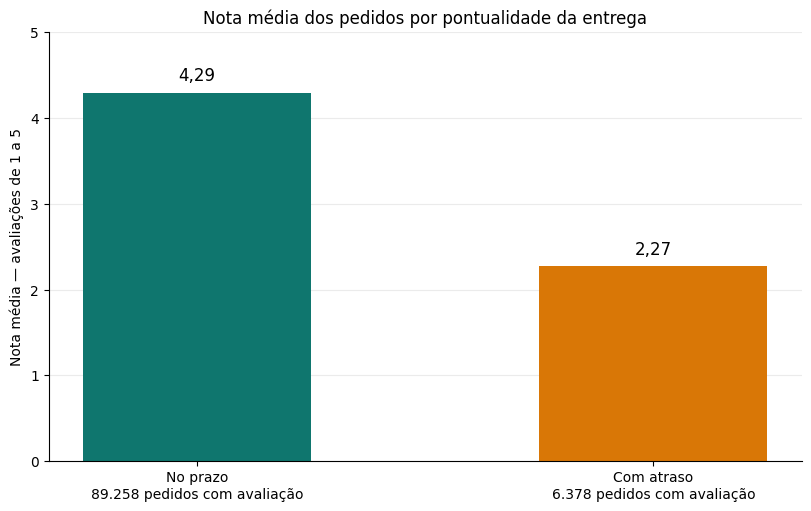

In [0]:
import matplotlib.pyplot as plt

dados_avaliacoes = (
    spark.table("olist_mvp.gold.avaliacoes_por_atraso")
    .toPandas()
    .set_index("situacao_entrega")
    .loc[["No prazo", "Com atraso"]]
)

notas = dados_avaliacoes["nota_media"].astype(float)

rotulos = [
    f"{situacao}\n"
    f"{int(quantidade):,} pedidos com avaliação".replace(",", ".")
    for situacao, quantidade in zip(
        dados_avaliacoes.index,
        dados_avaliacoes["pedidos_com_avaliacao"]
    )
]

figura, eixo = plt.subplots(
    figsize=(8, 5), constrained_layout=True
)

barras = eixo.bar(
    rotulos,
    notas,
    color=["#0F766E", "#D97706"],
    width=0.5
)

eixo.bar_label(
    barras,
    labels=[f"{nota:.2f}".replace(".", ",") for nota in notas],
    padding=6,
    fontsize=12
)

eixo.set_title("Nota média dos pedidos por pontualidade da entrega")
eixo.set_ylabel("Nota média — avaliações de 1 a 5")
eixo.set_ylim(0, 5)
eixo.set_yticks(range(6))
eixo.set_axisbelow(True)
eixo.grid(axis="y", alpha=0.25)
eixo.spines["top"].set_visible(False)
eixo.spines["right"].set_visible(False)

plt.show()

### Interpretação da relação entre atraso e avaliação

Os pedidos entregues no prazo apresentam nota média de 4,29, contra 2,27 nos pedidos atrasados, uma diferença de 2,02 pontos. Nesse recorte, o atraso está associado a avaliações consideravelmente menores.

O resultado sugere priorizar a investigação dos atrasos na gestão da experiência do cliente. Acompanhar os prazos e identificar etapas com maior incidência de problemas pode orientar melhorias operacionais.

A comparação é descritiva e não demonstra causalidade. Categoria do produto, vendedor, região e outros fatores podem influenciar tanto a entrega quanto a avaliação. Além disso, as médias representam apenas os pedidos com avaliações válidas e não mostram toda a distribuição das notas.

## Conclusão da camada Gold

As três análises permitiram responder às perguntas propostas.

### Como evoluíram os pedidos e o valor dos itens vendidos?

Houve crescimento ao longo de 2017, com pico de 7.289 pedidos
entregues em novembro e aproximadamente R$ 988 mil em itens vendidos.
Em 2018, os indicadores oscilaram em um patamar superior ao observado
no início de 2017, sem crescimento contínuo.

Os poucos registros de 2016 e a cobertura parcial de 2018 limitam
comparações anuais. O pico de novembro, isoladamente, não demonstra
um padrão sazonal recorrente.

### Quais categorias apresentaram maior valor de itens vendidos?

Beleza e saúde, Relógios e presentes e Cama, mesa e banho lideraram
o ranking, somando 25,89% do valor total de R$ 13.221.498,11.
As dez primeiras categorias representaram 62,43% desse total.

Essas participações ajudam a identificar categorias relevantes
para o acompanhamento comercial, mas não indicam lucratividade,
pois a análise não considera custos ou margens.

### Como as avaliações se relacionaram com os atrasos?

Entre os 96.281 pedidos incluídos na análise de pontualidade,
6.531 apresentaram atraso, correspondendo a 6,78%.

Nos pedidos com avaliações válidas, a nota média foi de 4,29
para entregas no prazo e de 2,27 para entregas atrasadas,
uma diferença de 2,02 pontos. O atraso médio dos pedidos
atrasados foi de 10,62 dias.

Os resultados mostram uma associação entre atraso e avaliações
mais baixas, indicando a relevância de investigar o desempenho
das entregas. Essa comparação é descritiva e não demonstra
causalidade.

### Limitações e próximos passos

Os resultados se restringem aos pedidos entregues presentes na
base histórica. O valor dos itens exclui frete e não representa
receita líquida ou lucro da Olist.

Na análise de pontualidade, foram excluídos 197 pedidos por datas
ausentes ou inconsistentes. Pedidos sem avaliação válida
permaneceram nas contagens de entregas, mas não participaram
das médias das notas.

Como continuidade, propõe-se investigar atrasos por região e
vendedor, examinar a distribuição das avaliações além das médias
e comparar a relação entre pontualidade e nota dentro de
diferentes categorias.

Foram salvas três tabelas Delta no esquema `olist_mvp.gold`:
`vendas_mensais`, `vendas_por_categoria` e `avaliacoes_por_atraso`.
Elas permitem reutilizar os indicadores em consultas e painéis.